# Number of assigned transcripts I

- using adata.X instead of manual boundary-transcript overlap
- faster but inaccurate in case of duplicate transcript assignments

In [1]:
from pathlib import Path

from cellseg_benchmark.metrics import (
    compute_metric_for_all_methods,
    compute_assigned_transcripts,
    plot_assigned_transcripts,
    plot_assigned_transcripts_heatmap
)
from cellseg_benchmark import BASE_PATH

/home/ubuntu/miniforge3/envs/seg_postprocessing/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [2]:
cohort = "aging"

## Compute

In [ ]:
%%time
compute_metric_for_all_methods(
    metric_func = compute_assigned_transcripts,
    cohort = cohort,
    base_path=Path(BASE_PATH),
    results_name = "assigned_transcripts/assigned_transcript_counts.csv",
    overwrite=True
              )

## Plot

### Overview

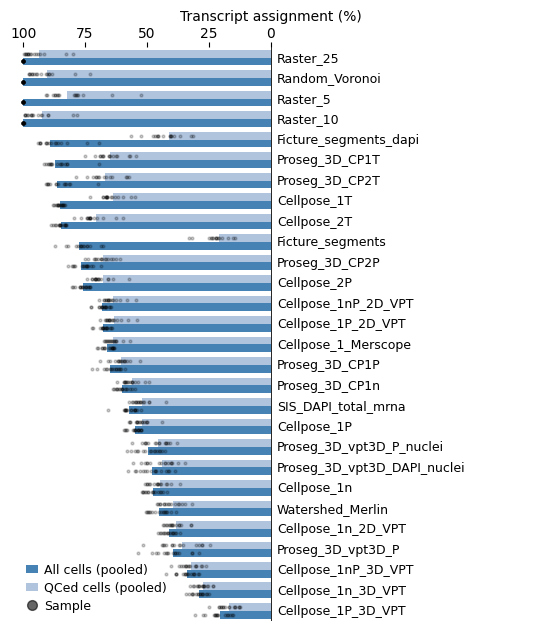

In [172]:
plot_assigned_transcripts(
    "aging",
    exclude_regex=r"Baysor",
    horizontal=True,
)

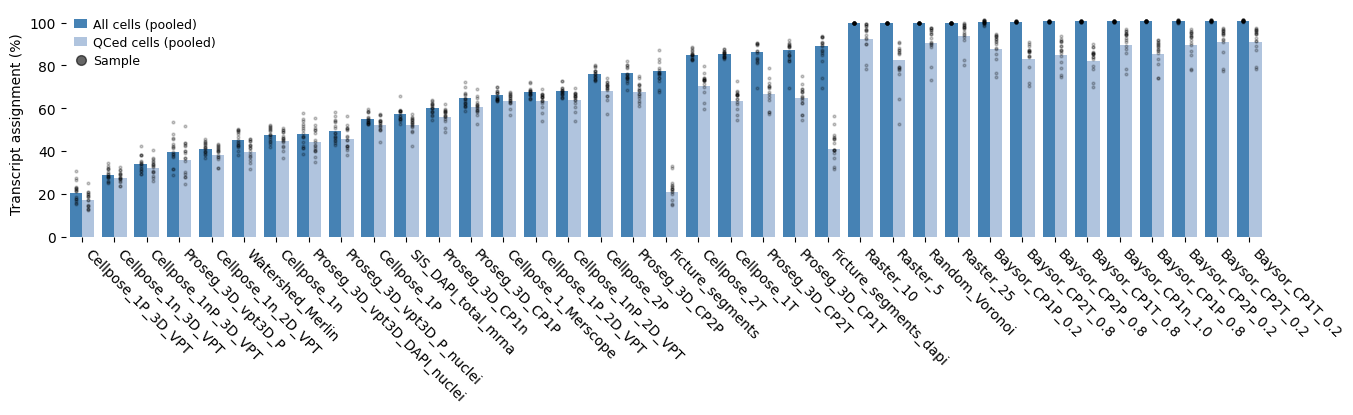

In [173]:
plot_assigned_transcripts(cohort=cohort, boxplot=False, show=True)

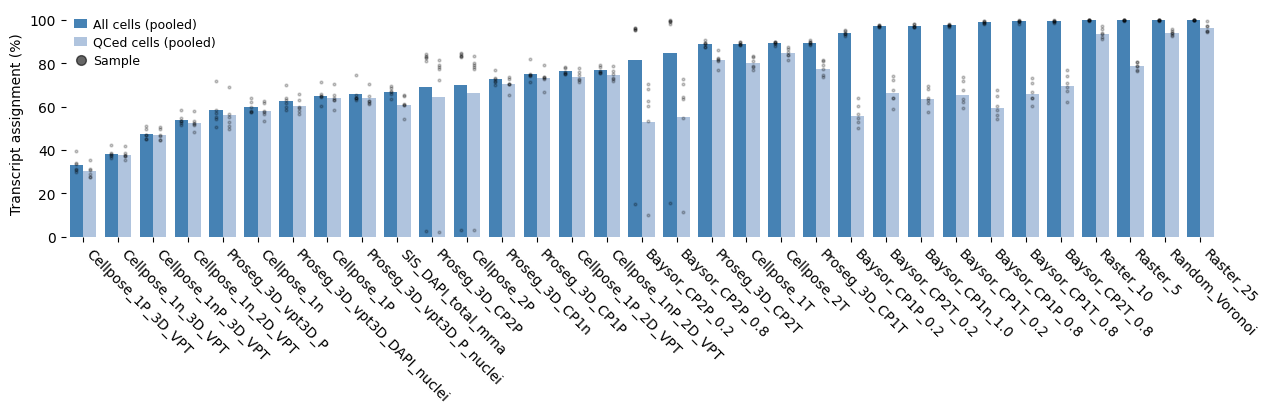

In [174]:
plot_assigned_transcripts(cohort="VizgenMouseBrain", boxplot=False, show=True)

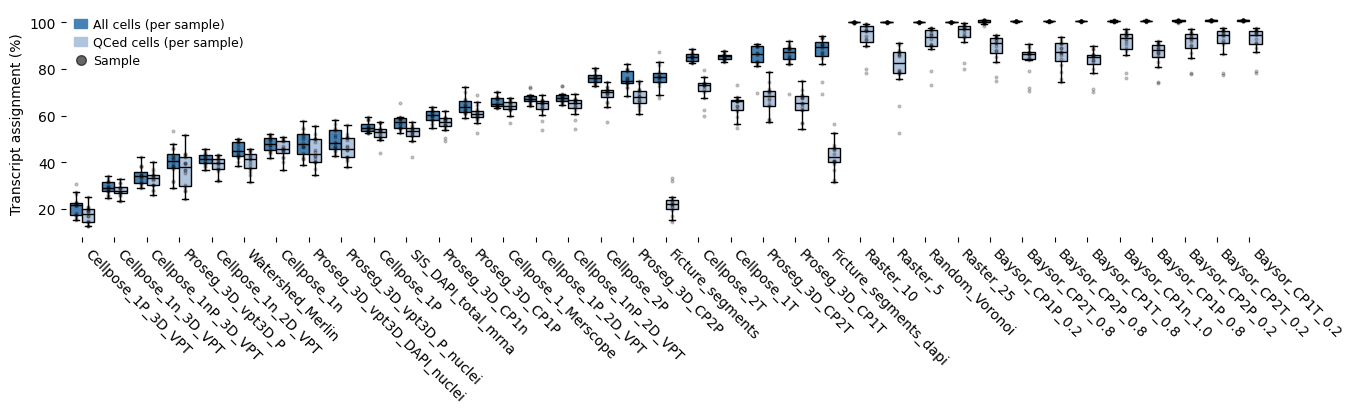

In [175]:
plot_assigned_transcripts(cohort=cohort, boxplot=True, show=True)

Note: Baysor assigns slightly more than 100% (max value 100.8%), meaning that some transcripts are assigned multiple times

### Per gene

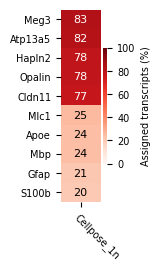

In [6]:
plot_assigned_transcripts_heatmap(cohort=cohort, method="Cellpose_1_nuclei_model", show=True, save=False)

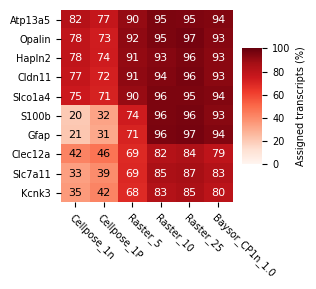

In [7]:
methods = ["Cellpose_1_nuclei_model", "Cellpose_1_DAPI_PolyT", "Negative_Control_Rastered_5", "Negative_Control_Rastered_10", "Negative_Control_Rastered_25", "Baysor_2D_Cellpose_1_nuclei_model_1.0"]
plot_assigned_transcripts_heatmap(cohort=cohort, method=methods, topn=5, show=True, save=False)